# Classic Loop vs Iteration Log

Sou-Cheng Choi 

May 3, 2026

In high-dimensional integration, achieving high precision in solution estimate often requires solving the same problem across a wide range of tolerances ($\epsilon$). Traditionally, this meant running the entire simulation multiple times, leading to prohibitive computational costs. This demo shows how implementing and using QMCPy's resume feature and internal solver logs can drastically reduce computational overhead while maintaining accuracy.

## Approach 1. Classic Loop
Use the same approach as in, for example, [MCQMC2022_Article_Figures.ipynb](../talk_paper_demos/MCQMC2022_Article_Figures/MCQMC2022_Article_Figures.ipynb), we will setup to create the two tolerance subplots:

1) Time vs tolerance and 
2) $n$ vs tolerance, each on log-log axes, with the Lattice and Lattice Parallel series plus the $\mathcal{O}(\epsilon^{-1})$ reference trend.

This naive approach requires re-running the solver for every target tolerance. This method suffers from poor scaling, making it impractical for large-scale parameter sweeps.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import qmcpy as qp

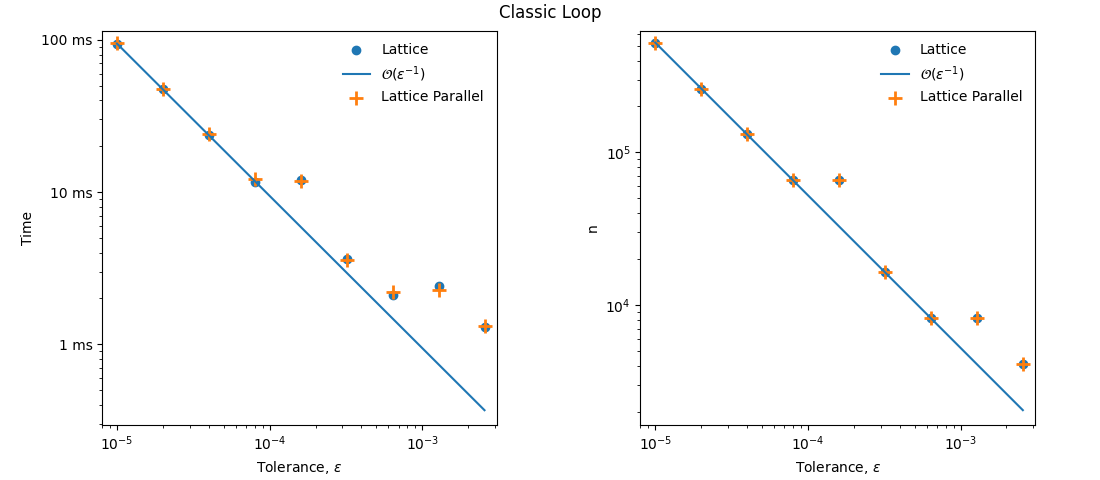

In [2]:
tol0, n_tol = 1e-5, 9
tol = np.array([tol0 * 2**i for i in range(n_tol)])

def run_lattice_tolerance_curve(seed):
    integ = qp.Keister(qp.Gaussian(qp.Lattice(3, seed=seed)))
    times, ns = [], []
    for eps in tol:
        _, data = qp.CubQMCLatticeG(integ, abs_tol=float(eps)).integrate()
        times.append(float(data.time_integrate))
        ns.append(float(data.n_total))
    return np.asarray(times), np.asarray(ns)

def _time_fmt(y, _):
    if y >= 1:      return f"{y:g} s"
    if y >= 1e-3:   return f"{y * 1e3:g} ms"
    return f"{y * 1e6:g} us"

ld_time,   ld_n   = run_lattice_tolerance_curve(seed=7)
ld_p_time, ld_p_n = run_lattice_tolerance_curve(seed=19)
ref_time = (ld_time[0] * tol[0]) / tol
ref_n    = (ld_n[0]   * tol[0]) / tol

fig1, ax = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
fig1.suptitle("Classic Loop")
for a, y1, y1p, ref, ylabel in zip(ax,
        [ld_time, ld_n], [ld_p_time, ld_p_n], [ref_time, ref_n], ["Time", "n"]):
    a.scatter(tol, y1,  color="tab:blue")
    a.plot(   tol, ref, color="tab:blue")
    a.scatter(tol, y1p, color="tab:orange", marker="+", s=100, linewidths=2)
    a.set_ylabel(ylabel)
    a.set_xlim([tol.min() * 0.8, tol.max() * 1.2])
    a.set_ylim([np.r_[y1, y1p, ref].min() * 0.8, np.r_[y1, y1p, ref].max() * 1.2])
    a.set_xlabel("Tolerance, " + r"$\varepsilon$")
    a.set_xscale("log"); a.set_yscale("log")
    a.legend(["Lattice", r"$\mathcal{O}(\varepsilon^{-1})$",
              "Lattice Parallel", r"$\mathcal{O}(\varepsilon^{-1})$"], frameon=False)
    a.set_box_aspect(1)

ax[0].yaxis.set_major_formatter(FuncFormatter(_time_fmt))
plt.show();


## Section 2. Resume Workflow

Run the solver once at the **loosest** tolerance, then **resume** at each progressively tighter tolerance. Because each resume starts from where the previous run left off, the cumulative elapsed time grows naturally — no redundant computation, and the solver only does the additional work required to tighten precision.

In [3]:
def collect_log_rows_resume(method_name, seed):
    """Start at the loosest tolerance, then resume at each tighter tolerance in sequence.
    elapsed_time is cumulative across all resume calls."""
    integ = qp.Keister(qp.Gaussian(qp.Lattice(3, seed=seed)))
    rows = []
    data = None
    for eps in tol[::-1]:  # loosest → tightest
        sc = qp.CubQMCLatticeG(integ, abs_tol=float(eps))
        if data is None:
            _, data = sc.integrate()
        else:
            _, data = sc.integrate(resume=data)
        rows.append({
            "method": method_name,
            "abs_tol": float(eps),
            "comb_bound_diff": float(data.comb_bound_diff),
            "elapsed_time": float(data.elapsed_time),
            "n_total": float(data.n_total),
        })
    return pd.DataFrame(rows)

iter_log = pd.concat(
    [collect_log_rows_resume("Lattice", seed=7),
     collect_log_rows_resume("Lattice Parallel", seed=19)],
    ignore_index=True,
).sort_values(["method", "abs_tol"]).reset_index(drop=True)

iter_log.head(18)


,method,abs_tol,comb_bound_diff,elapsed_time,n_total
0,Lattice,0.00001,0.000012,0.103990,524288.0
1,Lattice,0.00002,0.000026,0.052619,262144.0
2,Lattice,0.00004,0.000071,0.028530,131072.0
3,Lattice,0.00008,0.000142,0.016264,65536.0
4,Lattice,0.00016,0.000142,0.015514,65536.0
5,Lattice,0.00032,0.000458,0.006335,16384.0
6,Lattice,0.00064,0.001063,0.004151,8192.0
7,Lattice,0.00128,0.001063,0.003631,8192.0
8,Lattice,0.00256,0.004600,0.002073,4096.0
9,Lattice Parallel,0.00001,0.000012,0.106669,524288.0


For each panel we plot **elapsed time** (or **$n$**) vs. **tolerance $\varepsilon$**. The solver is run once at the loosest tolerance, then resumed at each tighter tolerance; each point reflects the cumulative time and sample count up to that stop. Both Lattice (seed 7) and Lattice Parallel (seed 19) series are overlaid with an $\mathcal{O}(\varepsilon^{-1})$ reference line on log-log axes.

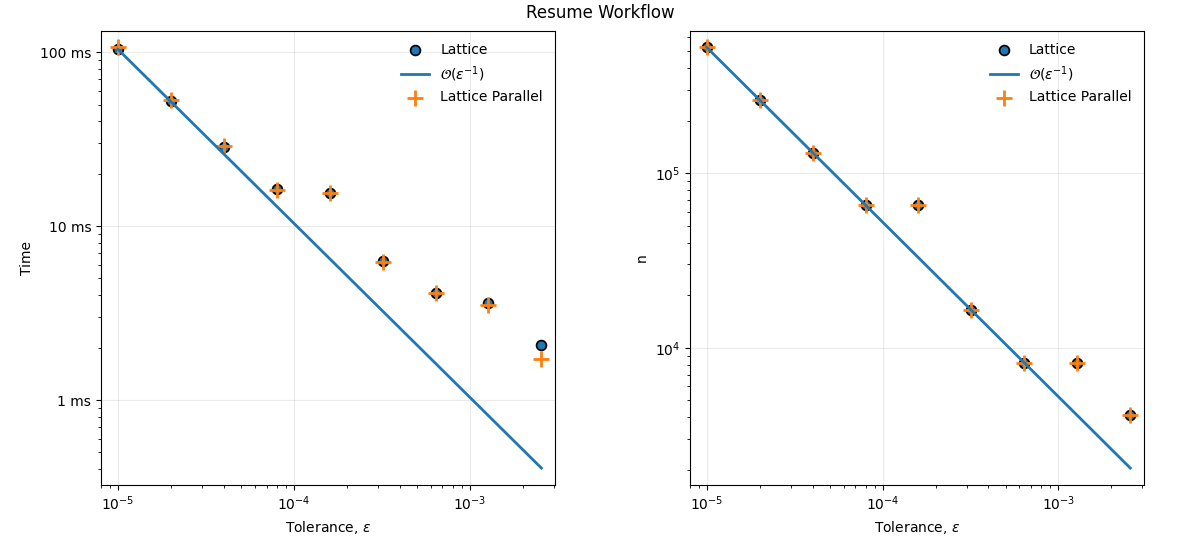

In [4]:
plot_df = iter_log.copy()
plot_df[["abs_tol", "elapsed_time", "n_total"]] = plot_df[
    ["abs_tol", "elapsed_time", "n_total"]].apply(pd.to_numeric, errors="coerce")
plot_df = plot_df.sort_values(["method", "abs_tol"])

methods = [
    ("Lattice",          "tab:blue",   "o",  50),
    ("Lattice Parallel", "tab:orange", "+", 140),
]

xcol = "abs_tol"

def draw_panel(ax_, ycol, ylabel):
    all_vals = []
    for method, color, marker, size in methods:
        d = plot_df[plot_df["method"] == method].sort_values(xcol)
        d.plot.scatter(x=xcol, y=ycol, ax=ax_, color=color, marker=marker, s=size,
                       linewidths=2 if marker == "+" else 1.25,
                       edgecolors="black" if marker == "o" else None)
        all_vals.extend(d[ycol])
        if color == "tab:blue":
            ref = d[ycol].iloc[0] * d[xcol].iloc[0] / d[xcol]
            d.assign(ref=ref).plot(x=xcol, y="ref", ax=ax_,
                                   color=color, legend=False, linewidth=2)
            all_vals.extend(ref)
    vals = np.asarray(all_vals, dtype=float)
    vals = vals[np.isfinite(vals) & (vals > 0)]
    ax_.set_ylim([vals.min() * 0.8, vals.max() * 1.25])
    ax_.set_ylabel(ylabel)
    ax_.grid(True, which="major", alpha=0.25)

fig2, ax = plt.subplots(1, 2, figsize=(12, 5.4), constrained_layout=True)
fig2.suptitle("Resume Workflow")
draw_panel(ax[0], "elapsed_time", "Time")
draw_panel(ax[1], "n_total", "n")

for a in ax:
    a.set_xlim([plot_df[xcol].min() * 0.8, plot_df[xcol].max() * 1.2])
    a.set_xlabel(r"Tolerance, $\varepsilon$")
    a.set_xscale("log"); a.set_yscale("log")
    a.legend(["Lattice", r"$\mathcal{O}(\varepsilon^{-1})$", "Lattice Parallel"], frameon=False)
    a.set_box_aspect(1)

ax[0].yaxis.set_major_formatter(FuncFormatter(_time_fmt))
plt.show();


Repeat Section 1 figure for side-by-side comparison.

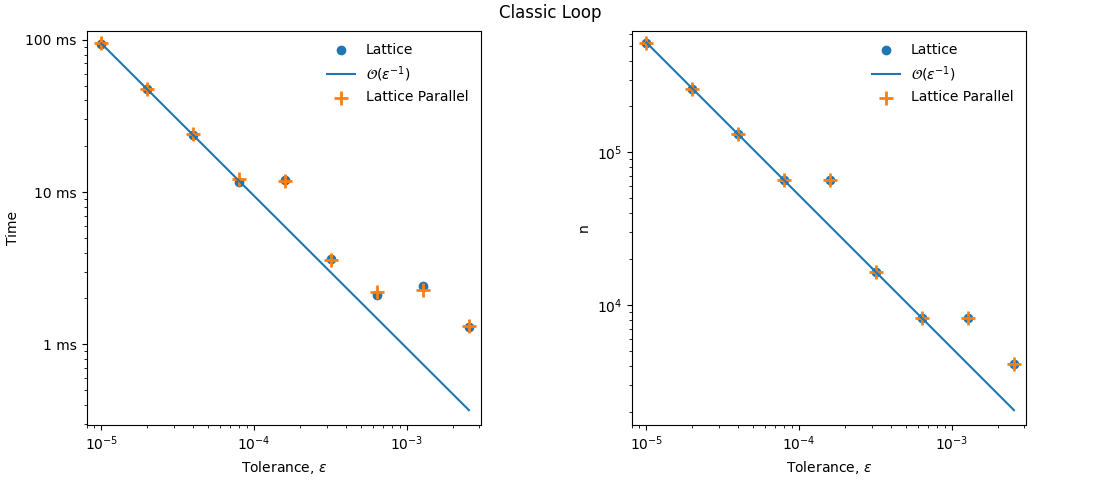

In [5]:

display(fig1)


# Conclusions

The Iteration Log with resume workflow in QMCPy represents a critical methodological advancement for computational simulations requiring multi-tolerance analysis. It transforms a computationally prohibitive task into an efficient process by leveraging internal solver data, allowing researchers to explore parameter space with unprecedented speed.